In [1]:
# STEP ONE : IMPORT MAIN LIBRARIES


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# DATAFRAME SAVED

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# QUESTION 1 : GENERATE SYNTHETIC DATASET USING MAKE_BLOBS

from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=0.70,
    random_state=42
)

# Convert into a DataFrame
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])

# Display the first 10 rows
print("First 10 Rows of the Dataset:")
print(df.head(10))

# Display the shape of the dataset
print("\nShape of the Dataset:")
print(df.shape)

First 10 Rows of the Dataset:
   Feature1  Feature2
0 -8.033836  6.831299
1 -8.767448 -6.918116
2  6.172741  1.407361
3 -2.783673  7.989826
4 -6.038777 -7.165762
5 -6.298392 -7.479368
6 -7.046269  7.256281
7 -6.690307 -6.915276
8  3.892545  1.873504
9 -7.317000 -6.861846

Shape of the Dataset:
(500, 2)


In [4]:
# QUESTION 2 : SCALING THE DATA OR X FEATURES

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create the scaler object
scaler = StandardScaler()

# Apply Standard Scaling
X_scaled = scaler.fit_transform(df)

# Display the first 5 rows of the scaled data
print("First 5 Rows of Scaled Data:")
print(X_scaled[0:5])

First 5 Rows of Scaled Data:
[[-0.88847363  0.62990684]
 [-1.02890768 -1.56287499]
 [ 1.83106858 -0.23511276]
 [ 0.11655663  0.81467072]
 [-0.5065627  -1.60237008]]


In [5]:
# QUESTION 3 : ELBOW METHOD TO FIND THE OPTIMAL NUMBER OF CLUSTERS

# Import KMeans
from sklearn.cluster import KMeans

# Create the KMeans model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit the model and predict cluster labels
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the DataFrame
df['Cluster'] = clusters

# Display the first 10 rows
print("First 10 Rows of the Updated DataFrame:")
print(df.head(10))

First 10 Rows of the Updated DataFrame:
   Feature1  Feature2  Cluster
0 -8.033836  6.831299        1
1 -8.767448 -6.918116        2
2  6.172741  1.407361        0
3 -2.783673  7.989826        1
4 -6.038777 -7.165762        2
5 -6.298392 -7.479368        2
6 -7.046269  7.256281        1
7 -6.690307 -6.915276        2
8  3.892545  1.873504        0
9 -7.317000 -6.861846        2


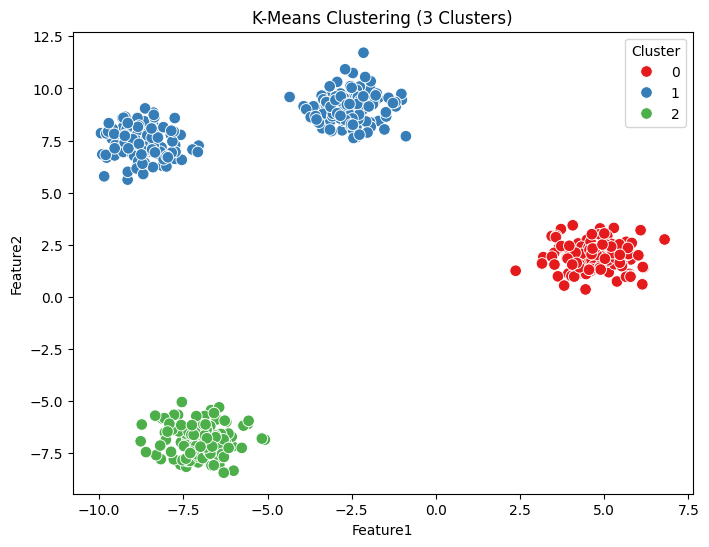

In [6]:
# QUESTION 4 : VISUALIZE THE CLUSTERS

# Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Create the scatter plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Feature1',
    y='Feature2',
    hue='Cluster',
    palette='Set1',
    s=70
)

# Add title and labels
plt.title("K-Means Clustering (3 Clusters)")
plt.xlabel("Feature1")
plt.ylabel("Feature2")

# Display the plot
plt.show()

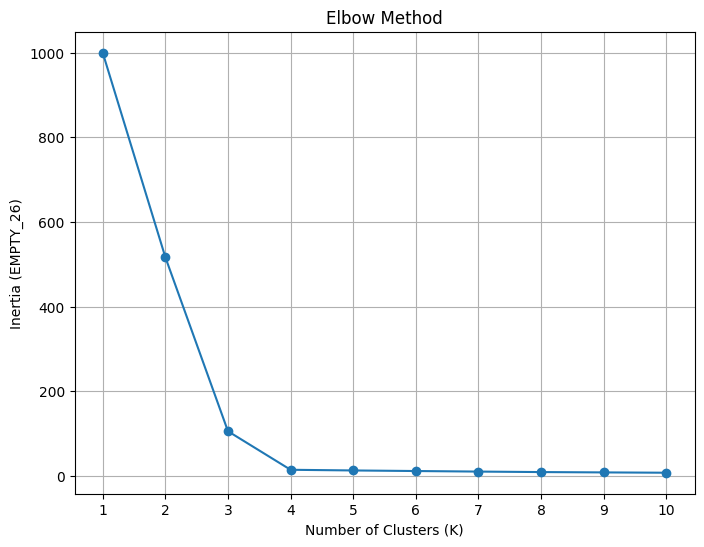

In [7]:
#QUESTION 5 : ELBOW METHOD TO FIND THE OPTIMAL NUMBER OF CLUSTERS

# Create an empty list to store WCSS (Inertia)
EMPTY_26 = []

# Calculate WCSS for K = 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    EMPTY_26.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(8, 6))

plt.plot(range(1, 11), EMPTY_26, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (EMPTY_26)")
plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

In [8]:
#QUESTION 6 : TRAIN THE FINAL KMEANS MODEL WITH THE OPTIMAL NUMBER OF CLUSTERS


# Train the final KMeans model with the optimal number of clusters
final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)



# Predict the cluster labels
final_clusters = final_kmeans.fit_predict(X_scaled)



# Add the final cluster labels to the DataFrame
df['Final_Cluster'] = final_clusters



# Display the first 10 rows
print("First 10 Rows of the Updated DataFrame:")
print(df.head(10))



# Print the number of data points in each cluster
print("\nNumber of Data Points in Each Cluster:")
print(df['Final_Cluster'].value_counts())

First 10 Rows of the Updated DataFrame:
   Feature1  Feature2  Cluster  Final_Cluster
0 -8.033836  6.831299        1              1
1 -8.767448 -6.918116        2              2
2  6.172741  1.407361        0              0
3 -2.783673  7.989826        1              3
4 -6.038777 -7.165762        2              2
5 -6.298392 -7.479368        2              2
6 -7.046269  7.256281        1              1
7 -6.690307 -6.915276        2              2
8  3.892545  1.873504        0              0
9 -7.317000 -6.861846        2              2

Number of Data Points in Each Cluster:
Final_Cluster
1    125
2    125
0    125
3    125
Name: count, dtype: int64


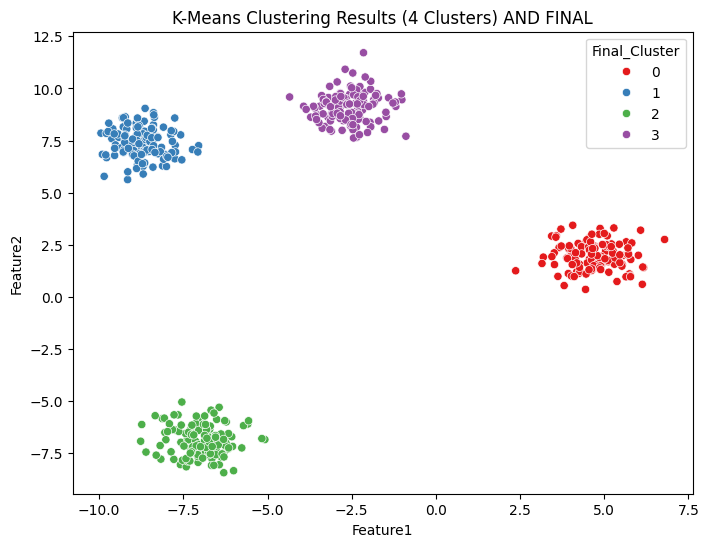

In [9]:
#QUESTION 7 : VISUALIZE THE FINAL CLUSTERS


plt.figure(figsize=(8,6))   # 8 BY 6

sns.scatterplot(            # sns.scatterplot(data,X,y,hue,palette)
    data=df,
    x='Feature1',
    y='Feature2',
    hue='Final_Cluster',
    palette='Set1'                #  set of colors for the clusters
)

plt.title("K-Means Clustering Results (4 Clusters) AND FINAL")
plt.xlabel("Feature1")
plt.ylabel("Feature2")

plt.show()

In [10]:
#QUESTION 8 : REAL DATASET APPLICATION

# Load the dataset
df = pd.read_csv("Mall_Customers.csv")

# Display the first 5 rows
print(df.head())



   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [11]:
# Select numerical features
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Scale the data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

In [12]:
# Create the KMeans model
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Predict cluster labels
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Display the number of customers in each cluster
print(df['Cluster'].value_counts())


Cluster
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64


In [13]:
#QUESTION 9 : ELBOW METHOD TO FIND THE OPTIMAL NUMBER OF CLUSTERS

# Create an empty list
EMPTY_WCSS = []



# Calculate WCSS for K = 1 to 10
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    EMPTY_WCSS.append(model.inertia_)

EMPTY_WCSS

[600.0,
 389.3861889564372,
 295.2122461555488,
 205.22514747675916,
 168.24758017556834,
 133.86842085478852,
 117.01155455889811,
 103.87329152383714,
 93.09289110041726,
 82.38515364526599]

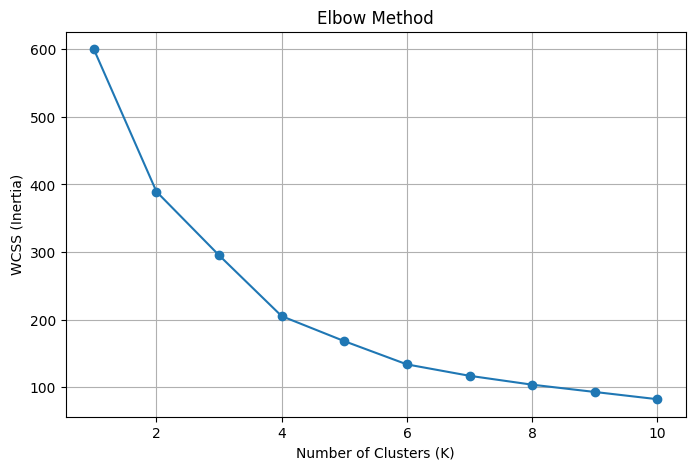

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1,11), EMPTY_WCSS, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")

plt.grid(True)
plt.show()

# Observation:
# The elbow point appears at K = 5.
# Therefore, the optimal number of clusters is 5.

In [15]:
# Train the final KMeans model
final_kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Predict cluster labels
PRED_CLUST=df['Final_Cluster'] = final_kmeans.fit_predict(X_scaled)

PRED_CLUST

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1,
       0, 1, 4, 1, 1, 1, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 4, 1,
       4, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1,
       1, 4, 4, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 4, 4, 1, 4, 1, 4, 4, 4, 4,
       4, 1, 3, 1, 1, 1, 4, 4, 4, 4, 1, 3, 2, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 4, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

In [16]:
# Display cluster sizes
print(df['Final_Cluster'].value_counts())

Final_Cluster
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64


In [17]:
#QUESTION 10 : VISUALIZE THE DATASET

import pandas as pd

# Load the dataset
customer_df = pd.read_csv("customer_segmentation.csv")

# Display the first 5 rows
print(customer_df.head())

# Display dataset information
print(customer_df.info())

# Display summary statistics
print(customer_df.describe())

# Check missing values
print(customer_df.isnull().sum())

# Fill missing values in Income column
customer_df['Income'] = customer_df['Income'].fillna(customer_df['Income'].median())

print(customer_df.isnull().sum())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

In [18]:
customer_X = customer_df[[
    'Income',
    'Recency',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth'
]]

In [19]:
from sklearn.preprocessing import StandardScaler

scaler_Customer = StandardScaler()

X_scaled_Customer = scaler_Customer.fit_transform(customer_X)

print(X_scaled_Customer.shape)

(2240, 13)


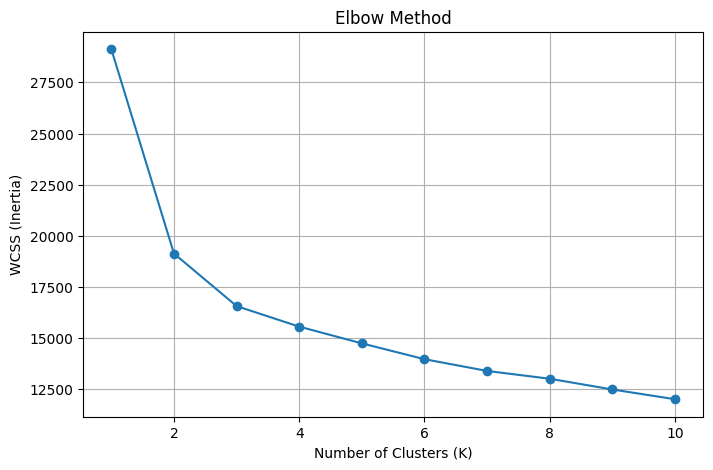

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss_Customer = []

for k in range(1, 11):
    customer_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    customer_model.fit(X_scaled_Customer)
    wcss_Customer.append(customer_model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss_Customer, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")

plt.grid(True)
plt.show()

In [21]:
# Train the final KMeans model
customer_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Predict cluster labels
customer_df['Cluster'] = customer_kmeans.fit_predict(X_scaled_Customer)

# Display cluster sizes
print(customer_df['Cluster'].value_counts())

Cluster
0    1013
2     478
1     473
3     276
Name: count, dtype: int64


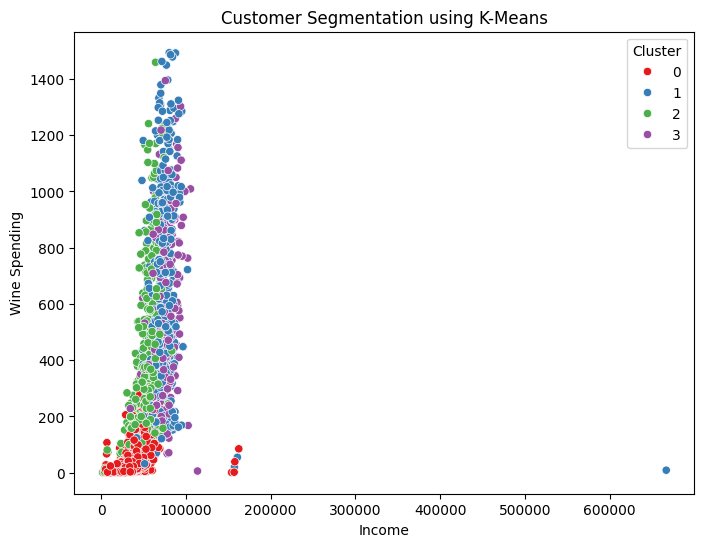

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customer_df,
    x='Income',
    y='MntWines',
    hue='Cluster',
    palette='Set1'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Income")
plt.ylabel("Wine Spending")

plt.show()

Observation:

The Customer Personality Analysis dataset was successfully clustered using K-Means.

Based on the Elbow Method, the optimal number of clusters is 4.

The scatter plot shows different customer segments based on Income and Wine Spending.